In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROBLEM FORMULATION.

We consider regression problem with likelihood function
and assume noisy variance is known
so
$$ p(y|x ,\theta )=N(y|x^T \theta, \sigma^2), ⇐⇒\begin{multline*}y=x^{T}\theta\;+\;\epsilon,\;\epsilon\;\sim\;N\left(0,\sigma^2\right)\\ \end{multline*}$$
suppose D:={ ($x_1,y_1$),($x_2,y_2$),($x_3,y_3$), , ,   ,  ,($x_n,y_n$)} are given training sets
$$\prod^N_{n=1} p(y_n|x_n ,\theta )=\prod^N_{n=1} N(y_n|x_n^T \theta, \sigma^2)$$

we solve for the $\theta$ $$\theta=arg\space max\space p(y|x ,\theta )$$
$$-\log{\prod^N_{n=1} p(y_n|x_n ,\theta )}=-log{\sum^N_{n=1} p(y_n|x_n ,\theta )}$$
$$\log p(y_n|x_n ,\theta )=-\frac{1}{2\sigma^2}(y_n-x_n^T\theta)^2 +constant$$
constant terms are independent of the $\theta$ so we ingonre them.
Using negative log-likelihood $$\mathcal{L(\theta)}:=\frac{1}{2\sigma^2}\sum^N_{n=1}(y_n-x_n^T\theta)^2
=\frac{1}{2\sigma^2}||y_n-x_n^T\theta||^2$$
Computing gardient of the $\mathcal{L}$ with respect to $\theta$
$$\frac{d\mathcal{L}}{d\theta}=\frac{1}{\sigma^2}(-y^TX+\theta^TX^TX)$$
solve for the $\theta$ by  using $\frac{d\mathcal{L}}{d\theta}=0^T$
 we get $$\theta=(X^TX)^{-1}X^Ty$$
Remark. The maximum likelihood solution  requires us to solve a system of linear equations of the form Aθ = b with A =$X^TX \space and \space b=X^Ty$

 Setting the gradient to 0⊤ is a necessary and sufficient condition,
 and we obtain a global minimum.
belwo  we will see the implementation of the above formula.

 

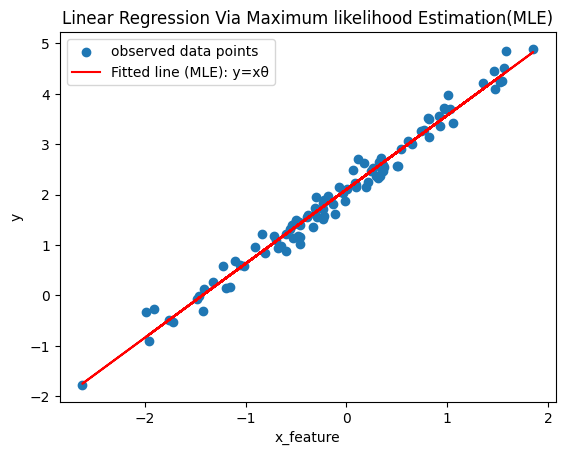

True value of parameters : [2.1 1.5]
Estimated value of  parameters via MLE: [2.10148557 1.47134857]


In [288]:
#The implementation of the maximum likelihood to estimate parameters 
np.random.seed(42)
#size of the sample points 
N=100
#randomly generated single features with N
x_feature=np.random.randn(N)

#add X_0 columns to X :-designing matrix (N,2) -
X=np.c_[np.ones(N),x_feature]
#noisy standard deviations(std) - std
sigma_mle=0.2

# intercept and slope values:- parameters value
theta_true=np.array([2.10, 1.5])#intercept=2.10, slope=1.50
#guassian noisy : mean is zero 
epsilon=np.random.normal(0,sigma_mle,size=N)

#y:= mx+b is linear regression 
y=X@theta_true + epsilon 
# MLE: solve (X^T X) theta = X^T y
A=X.T@X
b=X.T@y
#0_MLE:=(A^-1)bc- estimating theta by MLE
theta_mle=np.linalg.solve(A,b)
#predicted values of the y by using 0_MLE
y_hat=X@theta_mle
#plot for visualizing:
plt.plot(figsiz=(8,6))
plt.scatter(x_feature,y,label='observed data points')
plt.plot(x_feature,y_hat,'r',label='Fitted line (MLE): y=x\u03B8')
plt.xlabel('x_feature')
plt.ylabel('y')
plt.title('Linear Regression Via Maximum likelihood Estimation(MLE)')
plt.legend()
plt.show()
print(f'True value of parameters : {theta_true}\nEstimated value of  parameters via MLE: {theta_mle}')

Maximum likelihood Estimation with Features
- Linear Regression refers to Linear  in parameters in regression models but The inputs can undergo any nonlinear transformation,
for example polynomial functions.
So we do have 
$$ p(y|x,\theta)=N(y|\phi(x)^T\theta, \sigma^2)\space 
  \space where\space \phi \space is\space nonlinear\space transformation$$
We consider training inputs
 $$x_n\in \mathbb{R^D} \space and\space targets \space y_n \in \mathbb{ }R,n =1,2,....N,\space define\space the\space feature\space matrix(design\space matrix)$$   